In [72]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

for style in plt.style.available:
    print(style)

plt.style.use('classic')

Solarize_Light2
_classic_test_patch
_mpl-gallery
_mpl-gallery-nogrid
bmh
classic
dark_background
fast
fivethirtyeight
ggplot
grayscale
seaborn-v0_8
seaborn-v0_8-bright
seaborn-v0_8-colorblind
seaborn-v0_8-dark
seaborn-v0_8-dark-palette
seaborn-v0_8-darkgrid
seaborn-v0_8-deep
seaborn-v0_8-muted
seaborn-v0_8-notebook
seaborn-v0_8-paper
seaborn-v0_8-pastel
seaborn-v0_8-poster
seaborn-v0_8-talk
seaborn-v0_8-ticks
seaborn-v0_8-white
seaborn-v0_8-whitegrid
tableau-colorblind10


In [73]:


from typing import Iterable, Sized


@dataclass
class SimulationParameters:
    executors: int
    round_trip_time : float 
    database_size: int
    passwords_size: int
    mean_password_chars: int 
    mean_hash_time: float
    network_velocity: float
    disk_velocity: float
    cpu_speed: float
    hash_size : int 
    pass

@dataclass
class SimulationResult:
    total_time : float 
    comm_time : float 
    comp_time : float 
    speedup : float
    cc_ratio: float
    efficiency : float
    database_size : int 
    password_size : int 
    cost: float
    executors: int
    pass

class Simulation:
    def __init__(self, params: SimulationParameters):
        self.p = params
        pass

    def execute(self, executors, database_size)-> np.ndarray:
        results = np.empty((len(database_size),len(executors)),dtype=object)
        oldparams = self.p
        for i,ds in enumerate(database_size):
            for j,ex in enumerate(executors):
                self.p.executors = ex
                self.p.database_size = ds
                result = SimulationResult(
                    total_time=self.runtime(),
                    comm_time=self.t_comm(),
                    comp_time=self.t_comp(),
                    speedup=self.speedup(),
                    cc_ratio=self.t_comp()/self.t_comm(),
                    database_size=self.p.database_size,
                    password_size=self.p.passwords_size,
                    executors=self.p.executors,
                    efficiency=self.efficiency(),
                    cost= self.runtime() *  self.p.executors
                )
                results[i,j] = result
                pass
        self.p = oldparams
        return results
    
    def t_comm(self) -> float:
        return NotImplemented
    def t_comp(self) -> float:
        return NotImplemented
    def t_seq(self)->float:
        return NotImplemented
    def space(self)-> float:
        return NotImplemented
    

    def runtime(self)-> float :
        return self.t_comp() + self.t_comm()
    def speedup(self) -> float:
        return self.t_seq()/self.runtime()
    def efficiency(self) -> float:
        return (self.speedup() / self.p.executors)*100
    def L(self,x):
        return x/ self.p.disk_velocity
    def S(self,x):
        return x / self.p.network_velocity
    def H(self,x):
        return self.p.mean_hash_time * x
    def C(self,x,y):
        return ((x*y)*self.p.hash_size)/(self.p.cpu_speed)

    pass


sha256_sim_param = SimulationParameters(
    executors=1,
    round_trip_time=1*10**-5,
    database_size=1,
    passwords_size=10000,
    mean_password_chars=16,
    mean_hash_time=0.81*10**-3, # seconds
    network_velocity=2.5*10**9,  # GB/s
    disk_velocity=700*10**6,       # MB/s
    cpu_speed=2.3*10**9,            # GHz
    hash_size=32  ,                 # bytes
)




In [74]:
class SequentialSimulation(Simulation):
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size, self.p.passwords_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass

sim = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[10**i for i in range(1,10)])
print(f"Runtime {sim[8,0].comp_time}, Tcomm {sim[8,0].comm_time}")


Runtime 139138.5347826087, Tcomm 45.71451428571429


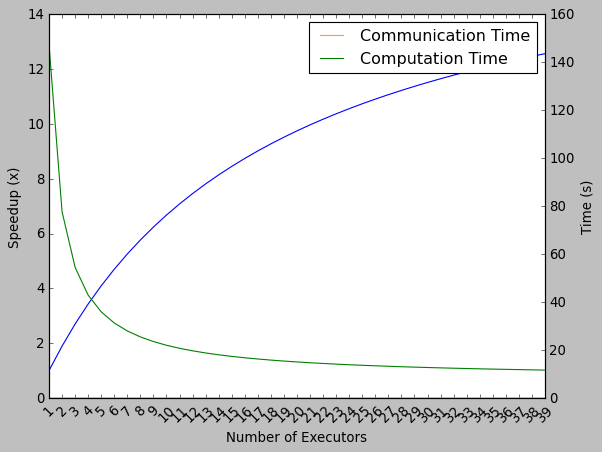

In [75]:
from matplotlib.pyplot import xlabel, ylabel

class LinearSimulation(SequentialSimulation):
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars)*self.p.executors  + self.S(self.p.database_size*self.p.hash_size)+ 2 * self.p.round_trip_time * self.p.executors
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size)
    pass



scale = LinearSimulation(sha256_sim_param).execute([i for i in range(1,40)], np.arange(10**6,10**7,10**4))

def plot_speedup(scale,index):
# set labels in plot
    xlabel('Number of Executors')
    ylabel('Speedup (x)')
    plt.plot([x for x in range(len(scale[index]))], [x.speedup for x in scale[index]] , label='Speed Up')
    # add to x the correct labels
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.legend()
    # add third axis 
    plt.twinx()
    plt.ylabel('Time (s)')
    plt.plot([x for x in range(len(scale[index]))], [s.comm_time for s in scale[index]], label='Communication Time', color='orange')
    plt.plot([x for x in range(len(scale[index]))], [s.comp_time for s in scale[index]], label='Computation Time', color='green')
    plt.legend()
    plt.show()

plot_speedup(scale,0)  # Plot for the first instance of scale

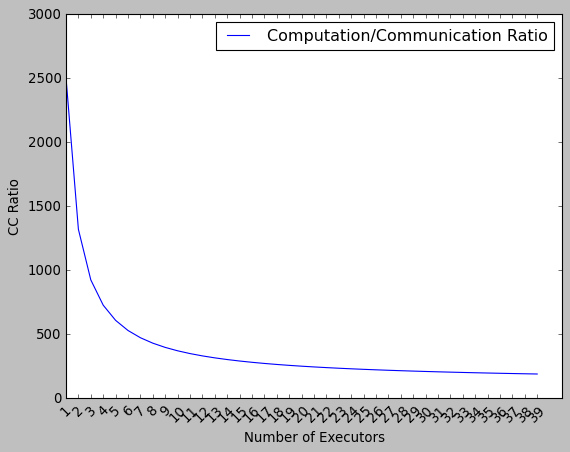

In [76]:
def plot_cc_ratio(scale,index):
    plt.plot([x for x in range(len(scale[index]))], [s.cc_ratio for s in scale[index]], label='Computation/Communication Ratio')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=45)
    plt.xlabel('Number of Executors')
    plt.ylabel('CC Ratio')
    plt.legend()
    plt.show()

plot_cc_ratio(scale,0)  # Plot for the first instance of scale

[np.float64(0.9999125258701376), np.float64(1.8948604630080732), np.float64(2.7005446003836857), np.float64(3.429683043049515), np.float64(4.0926873761433935), np.float64(4.698162866105737), np.float64(5.253283902285756), np.float64(5.764079533663778), np.float64(6.235653253902081), np.float64(6.672354046220831), np.float64(7.077910848855758), np.float64(7.455539253619181), np.float64(7.80802690445249), np.float64(8.137802396988944), np.float64(8.446991281984689), np.float64(8.737461903533378), np.float64(9.010863161466613), np.float64(9.268655810526523), np.float64(9.51213855110011), np.float64(9.74246989540855), np.float64(9.960686586213598), np.float64(10.16771918593408), np.float64(10.364405330659446), np.float64(10.551501047193435), np.float64(10.729690455526926), np.float64(10.89959411923573), np.float64(11.06177625863311), np.float64(11.216751003362315), np.float64(11.36498783042379), np.float64(11.506916308811162), np.float64(11.64293025175785), np.float64(11.773391361124917), 

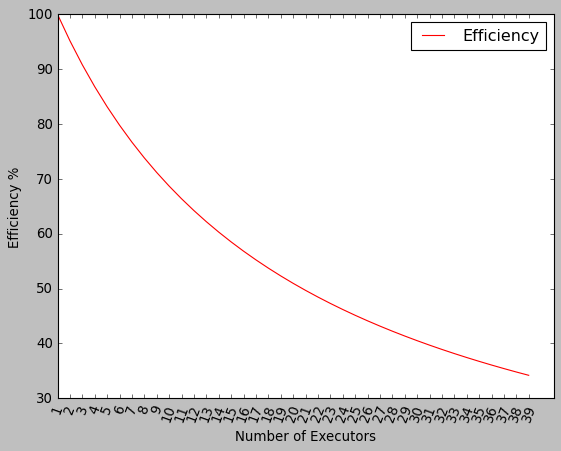

In [77]:
def plot_efficiency(scale,index):
    efficiency = [s.efficiency for s in scale[index]]
    plt.plot([x for x in range(len(efficiency))], efficiency, label='Efficiency', color='red')
    plt.xlabel('Number of Executors')
    plt.xticks([x for x in range(len(scale[index]))], [f"{int(s.executors)}" for s in scale[index]], rotation=70)
    plt.ylabel('Efficiency %')
    plt.legend()
    plt.show()

print([s.speedup for s in scale[0]])
plot_efficiency(scale,10)  # Plot for the first instance of scale

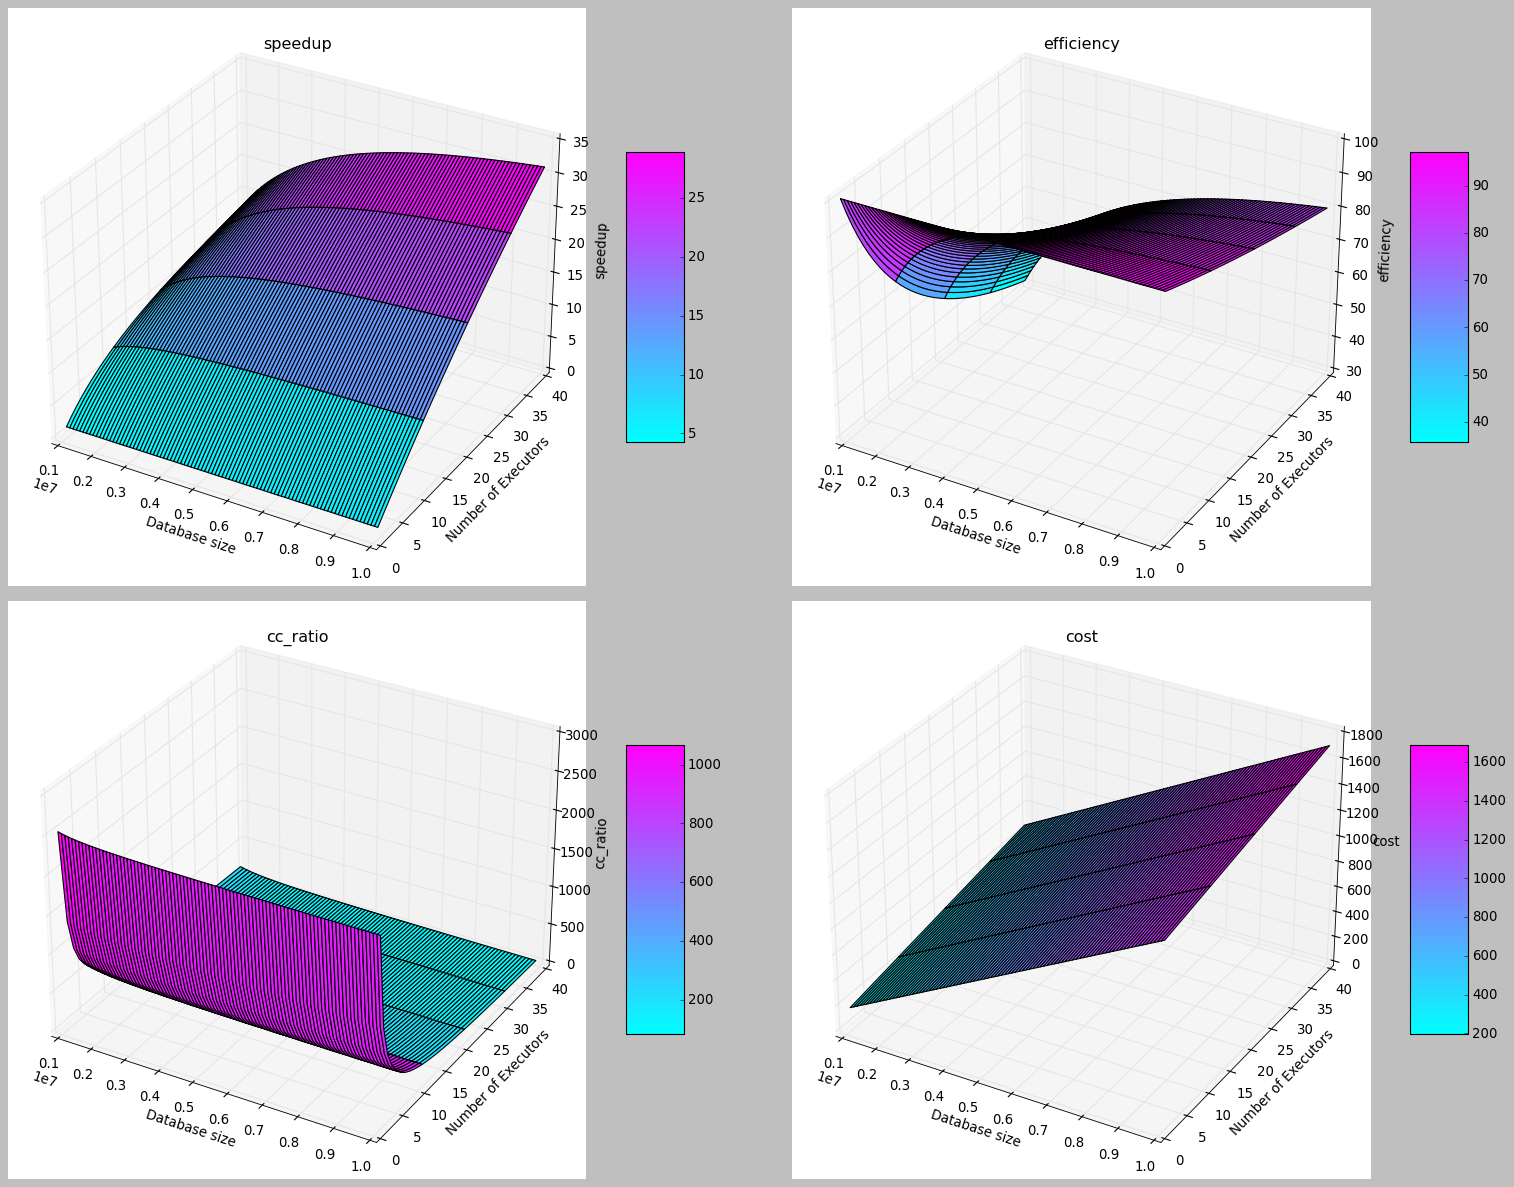

In [78]:
import math
from numpy import meshgrid


def plot_measure(result: np.ndarray, measure: str):

    X_vals = [x[0].database_size for x in result]
    Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
    Z = np.zeros((len(X_vals), len(Y_vals)))
    for i in range(len(X_vals)):
        for j in range(len(Y_vals)):
            Z[i, j] = result[i][j].__getattribute__(measure)
    print("X shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)
    print("Z min/max:", np.nanmin(Z), np.nanmax(Z))
    fig = plt.figure()
    ax = fig.add_axes((0, 0, 2, 2), projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Database size')
    ax.set_ylabel('Number of Executors')
    ax.set_zlabel(measure)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()


def plot_all_measures(result: np.ndarray):
    X_vals = [x[0].database_size for x in result]
    Y_vals = [x.executors for x in result[0]]  # <-- non dividere per 10
    X, Y = np.meshgrid(X_vals, Y_vals, indexing='ij')
    Zs = {}
    for measure in ['speedup', 'efficiency', 'cc_ratio', 'cost']:
        Z = np.zeros((len(X_vals), len(Y_vals)))
        for i in range(len(X_vals)):
            for j in range(len(Y_vals)):
                Z[i, j] = result[i][j].__getattribute__(measure)
        Zs[measure] = Z
    fig = plt.figure(figsize=(20, 15))
    for idx, (measure, Z) in enumerate(Zs.items(), start=1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        surf = ax.plot_surface(X, Y, Z, cmap='cool')
        ax.set_xlabel('Database size')
        ax.set_ylabel('Number of Executors')
        ax.set_zlabel(measure)
        ax.set_title(f'{measure}')
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()
    
    
plot_all_measures(scale)

In [79]:
class RingSimulation(SequentialSimulation):

    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.round_trip_time * self.p.executors + self.t_transitory()
    
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors)*self.p.executors

    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors) + self.S(self.p.database_size/self.p.executors) + self.p.round_trip_time * self.p.executors
    pass

scale = RingSimulation(sha256_sim_param).execute([i for i in range(1,40)], np.arange(10**6,10**7,10**4))

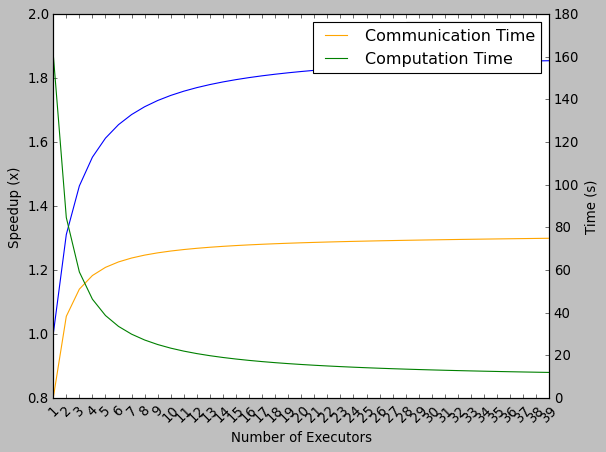

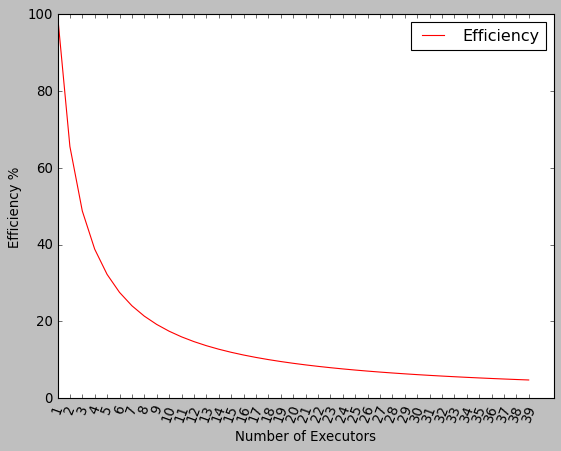

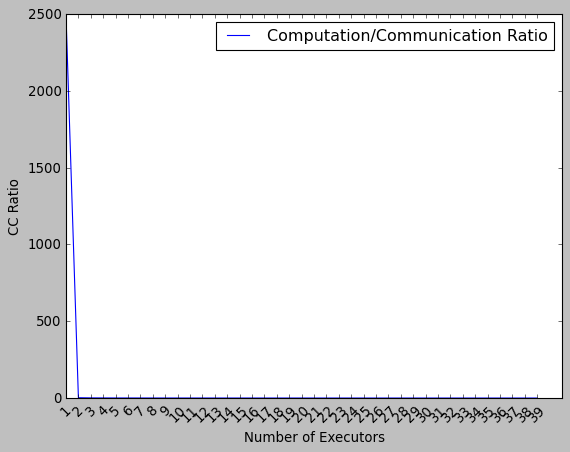

In [80]:
plot_speedup(scale,10)  # Plot for the first instance of scale
plot_efficiency(scale,10)  # Plot for the first instance of scale
plot_cc_ratio(scale,10)  # Plot for the first instance of scale

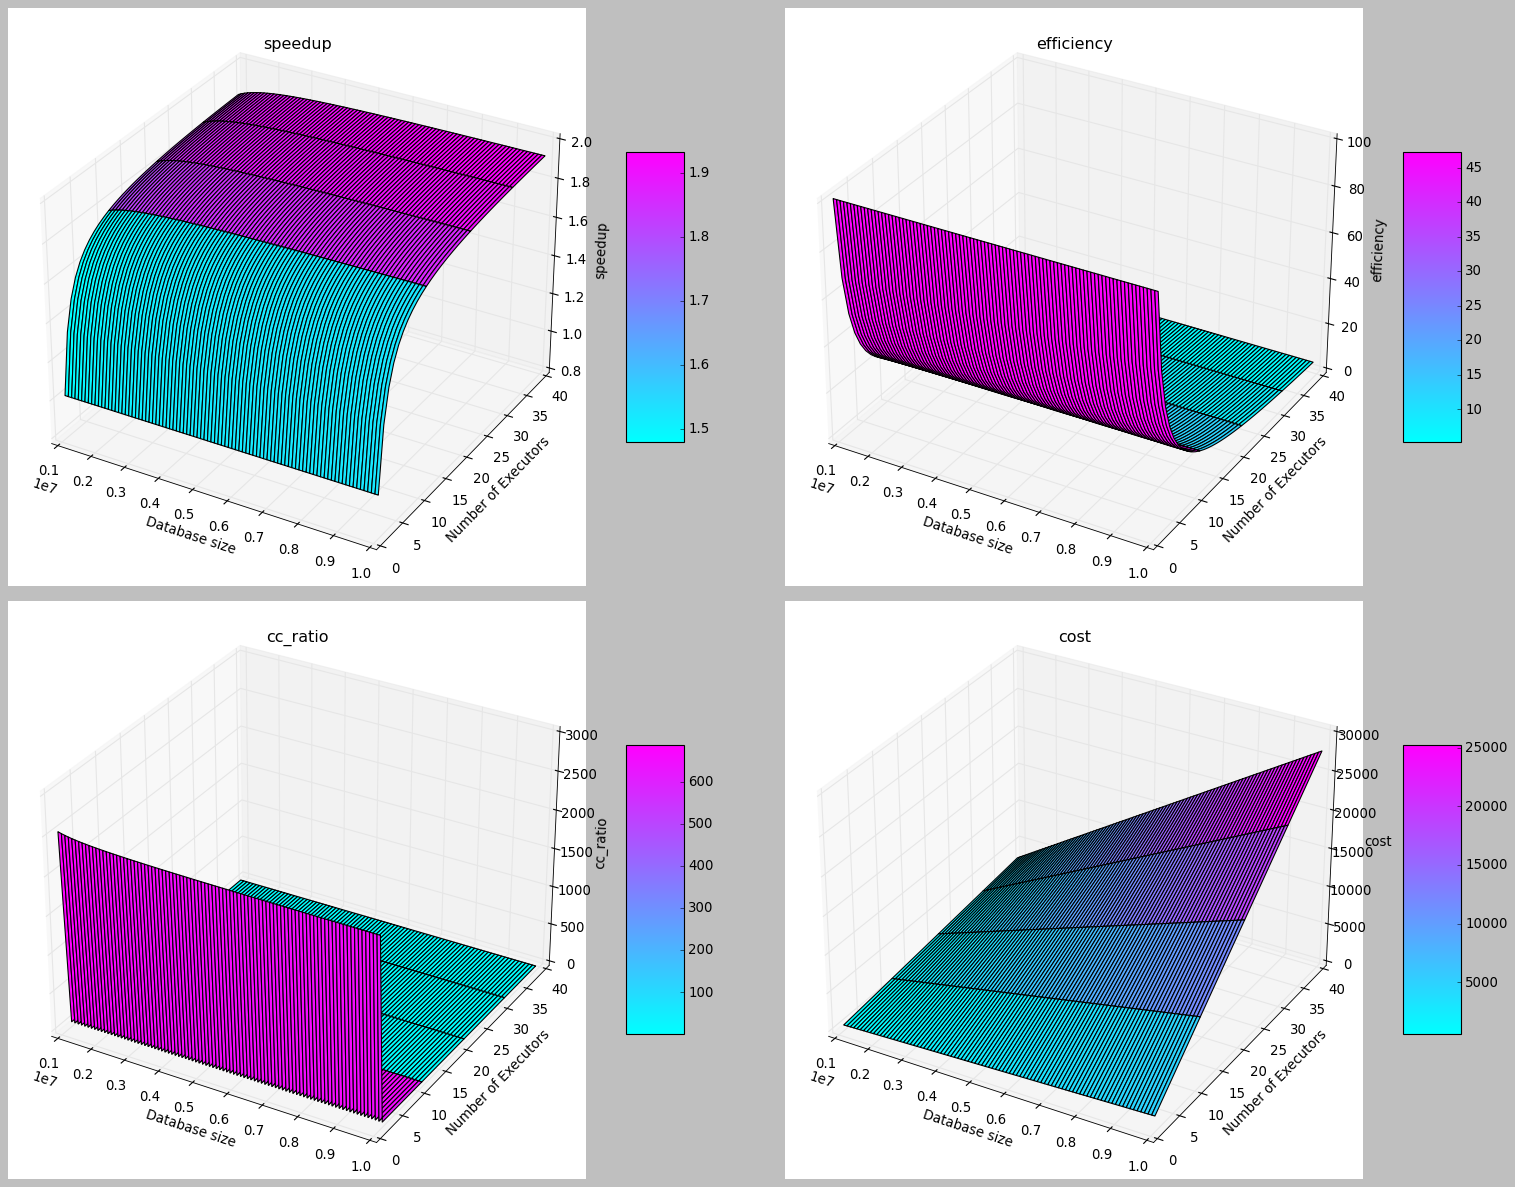

In [81]:
plot_all_measures(scale)

In [82]:
class BlockRingSimulation(SequentialSimulation):
    task_size = 2000
    
    def t_comm(self) -> float:
        return self.L(self.p.passwords_size*self.p.mean_password_chars) + self.L(self.p.database_size*self.p.hash_size) + self.S(self.p.passwords_size*self.p.mean_password_chars) + self.S(self.p.database_size*self.p.hash_size/self.p.executors)+ 2 * self.p.round_trip_time * self.p.executors + self.t_transitory()
    
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors)*self.p.executors

    def t_transitory(self)-> float:
        return self.t_task()*((self.p.executors-1)*self.p.executors)/2

    def t_task(self)->float:
        return self.C(self.p.database_size/self.p.executors, self.p.passwords_size/self.p.executors) + self.S(self.p.database_size/self.p.executors) + self.p.round_trip_time * self.p.executors
    pass

$T_{seq}= L(N)+H(N)+L(K)+H(K)+C_h(K,N)$

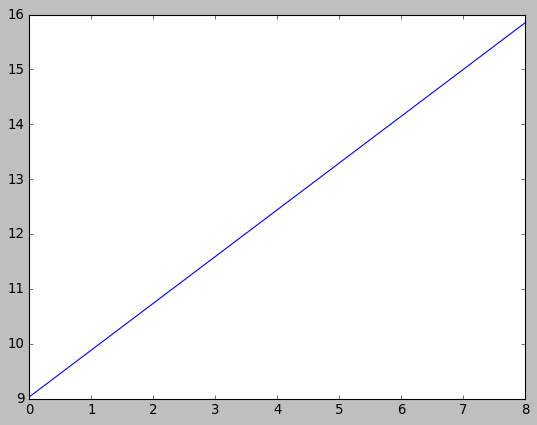

In [83]:




class DHTSequentialSimulation(Simulation):
    def __init__(self, params: SimulationParameters, hashmap_size=10**6):
        super().__init__(params)
        self.hashmap_size = hashmap_size
        pass
    @staticmethod
    def p_collision(keys,size):
        prob = 1 - math.exp(- (keys*(keys-1)) / (2*size))
        return prob
    
    @staticmethod
    def expected_collision(keys,size):
        coll = keys-size+size*((size-1)/size)**keys
        return coll if coll > 1 else 1
    
    def Ch(self, k: int, alloc_size: int)-> float:
        return ((k*self.expected_collision(self.p.database_size,alloc_size)))/(self.p.cpu_speed/8)
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 
    
    def I(self, x):
        return x* 8* 10**-6 #microseconds

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size,self.hashmap_size) + self.H(self.p.database_size) + self.I(self.p.passwords_size) + self.I(self.p.database_size)

    def t_seq(self) -> float:
        return self.t_seq_comm() + self.t_seq_comp()
    def t_comm(self) -> float:
        return self.t_seq_comm()
    def t_comp(self) -> float:
        return self.t_seq_comp()
    pass

res = DHTSequentialSimulation(sha256_sim_param,10**1).execute([x for x in range(1,100)],[1000*i for i in range(1,100)])
seq = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,100)],[1000*i for i in range(1,100)])
plt.plot([x for x in range(9)], [res[x,10].total_time for x in range(9)], label='time')
plt.show()

$T_{comp}=H(N)+H(K)+C_h(K,N)$
$T_{comm}= L(N)+L(K)+S(N)+S(K)$

Runtime 906.2166137429524, Tcomm 0.0019931428571428574, Seq 158.4104695652174
Excpected collisions  367879.25722106645 Probaility  1.0


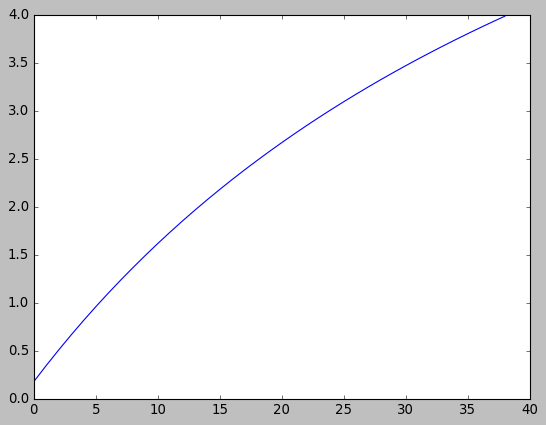

In [84]:
from numpy import ndarray



class DHTSimulation(DHTSequentialSimulation,SequentialSimulation):
    def __init__(self, params: SimulationParameters, hashmap_size=10 ** 6):
        super().__init__(params, hashmap_size)
        pass
    
    def t_seq_comm(self) -> float:
        return self.L(self.p.database_size*self.p.hash_size) + self.L(self.p.passwords_size*self.p.mean_password_chars) 

    def t_seq_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.C(self.p.database_size, self.p.passwords_size)

    def t_comm(self) -> float:
        return self.L(self.p.passwords_size)+ self.L(self.p.database_size) + self.S(self.p.passwords_size) + self.S(self.p.database_size)
    def t_comp(self) -> float:
        return self.H(self.p.passwords_size) + self.Ch(self.p.passwords_size,self.hashmap_size*self.p.executors) + self.H(self.p.database_size/self.p.executors) + self.I(self.p.passwords_size) + self.I(self.p.database_size)    
    pass
seq = SequentialSimulation(sha256_sim_param).execute([x for x in range(1,40)],np.arange(10**6,10**7,10**4))
sim = DHTSimulation(sha256_sim_param,10**6).execute([i for i in range(1,40)],np.arange(10**6,10**7,10**4))
print(f"Runtime {sim[8,0].total_time}, Tcomm {sim[8,0].comm_time}, Seq {seq[8,0].total_time}")
print("Excpected collisions ", DHTSimulation.expected_collision(10**6,10**6) , "Probaility ", DHTSimulation.p_collision(10**6,10**6))
#plot speedup
plt.plot([x for x in range(len(sim[8]))], [ x.speedup for x in sim[8]] , label='Speed Up')

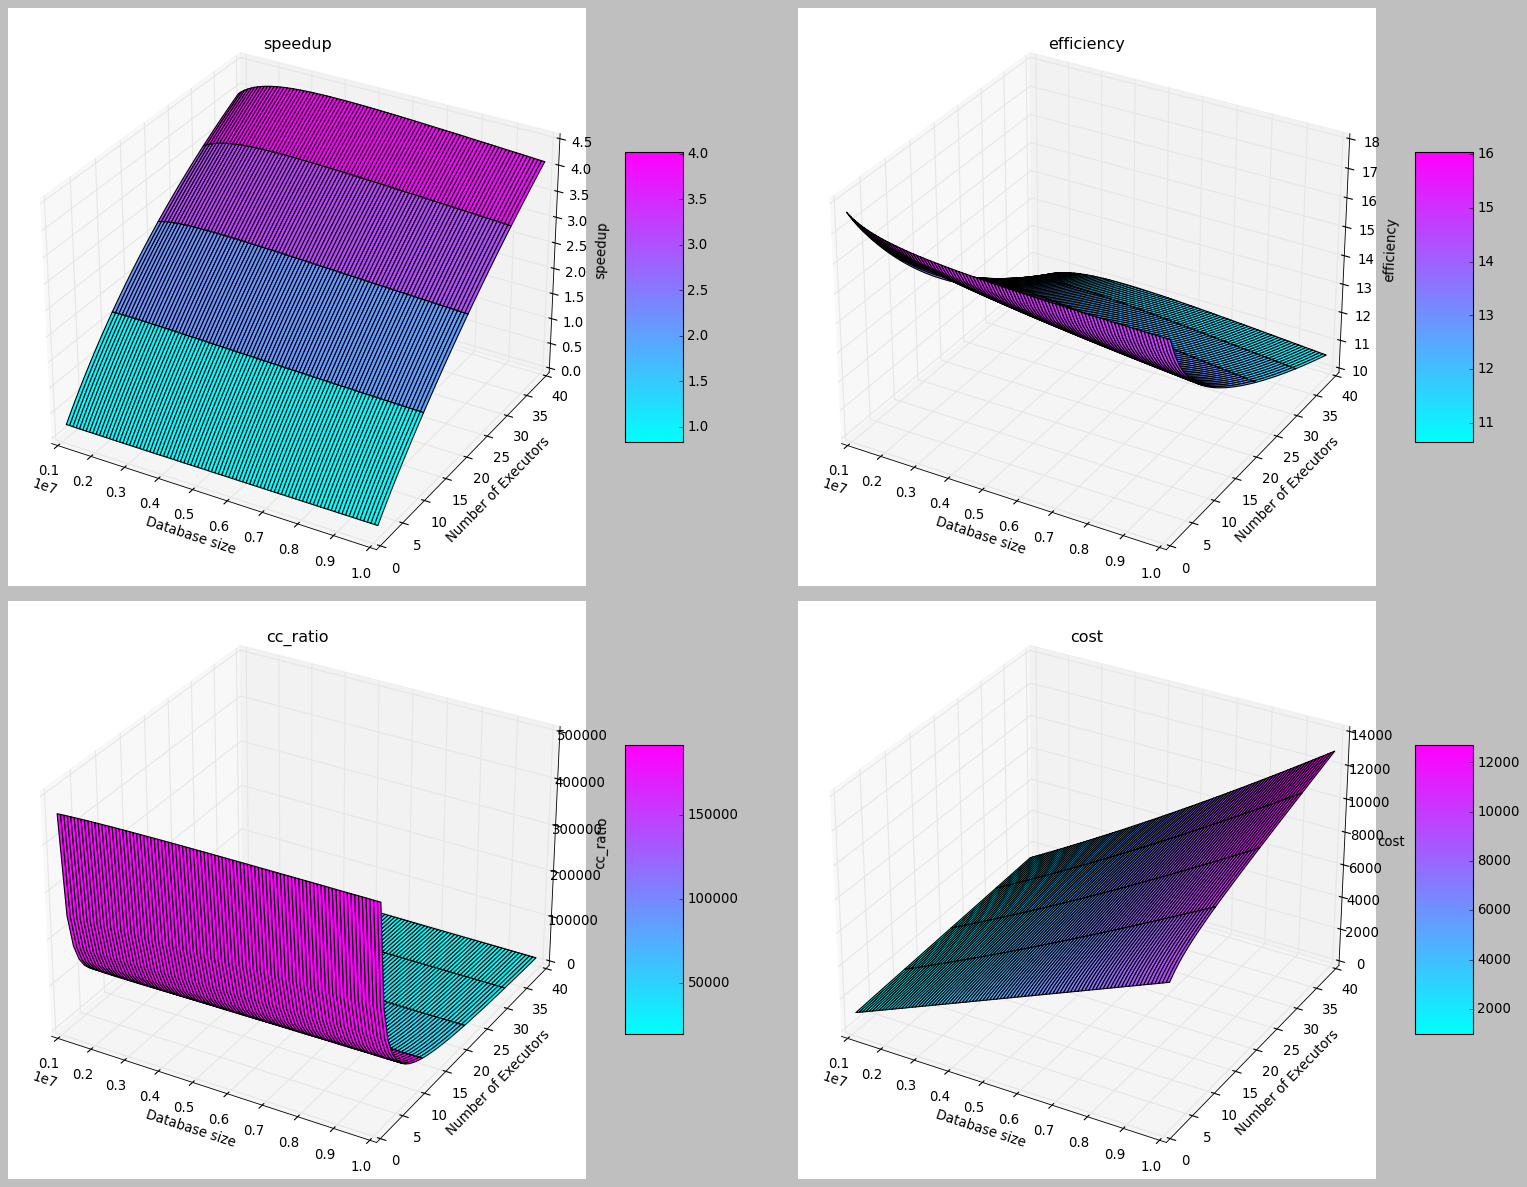

In [85]:
plot_all_measures(sim)